In [1]:
from circuit_opt import *
from benchmark import *

/Users/parton/KEIO-UCL/QCircOptForPartitioning/LC_Partitioning/circuit_opt.py:98: RuntimeWarning: divide by zero encountered in matmul
  phase = np.angle(np.trace(np.conjugate(U2).T @ U1))
/Users/parton/KEIO-UCL/QCircOptForPartitioning/LC_Partitioning/circuit_opt.py:98: RuntimeWarning: overflow encountered in matmul
  phase = np.angle(np.trace(np.conjugate(U2).T @ U1))
/Users/parton/KEIO-UCL/QCircOptForPartitioning/LC_Partitioning/circuit_opt.py:98: RuntimeWarning: invalid value encountered in matmul
  phase = np.angle(np.trace(np.conjugate(U2).T @ U1))


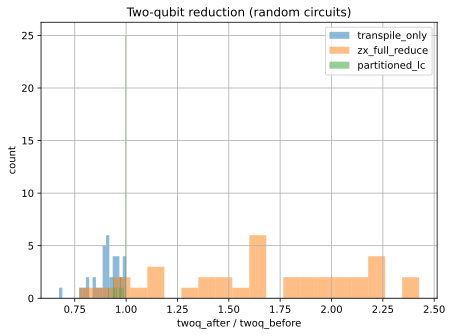

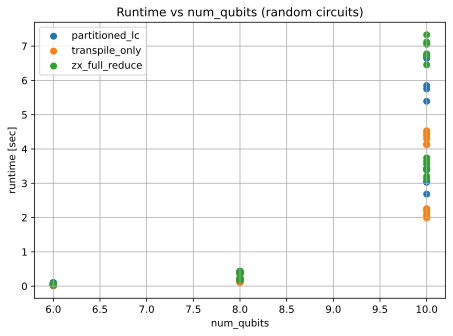

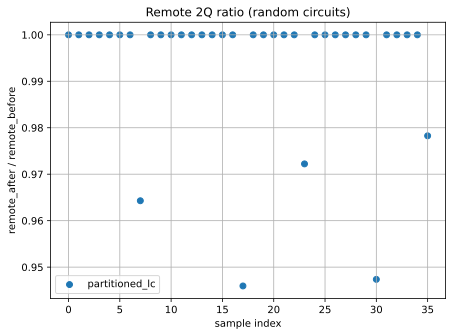

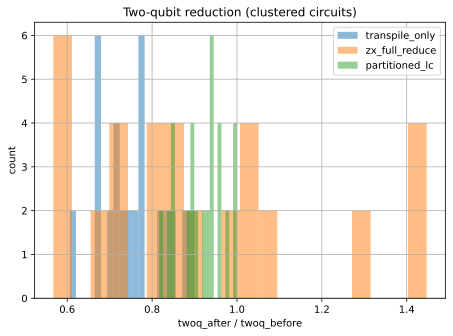

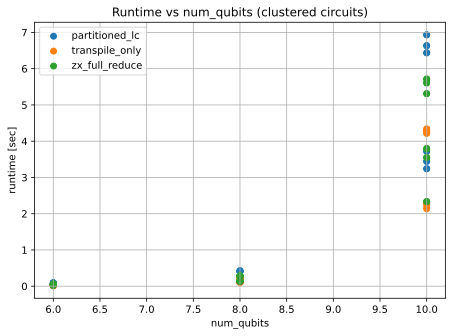

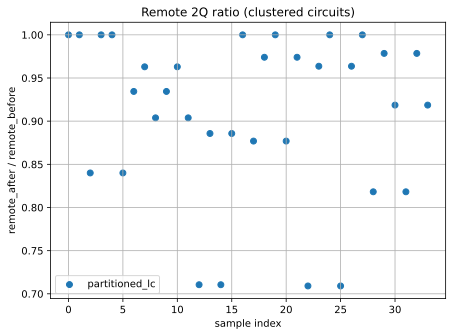

In [2]:

# --------------------------------------------
# 設定
# --------------------------------------------
nq_list = [6, 8, 10]
depth_list = [20, 40]
dens_list = [0.3, 0.7]

# クラスタ回路用設定
processors = 2
intra_density = 0.8
inter_density = 0.05

# --------------------------------------------
# パイプライン定義
# --------------------------------------------

def _transpile_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return transpile_only_pipeline(qc)

def _zx_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return lc_pipeline(qc)

def _partitioned_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return partitioned_lc_pipeline(qc, processors=processors)

# --------------------------------------------
# (1) 完全ランダム回路でのベンチマーク
# --------------------------------------------
samples_random = []
for pipe_fn in [_transpile_wrapper, _zx_wrapper, _partitioned_wrapper]:
    samples = benchmark_pipeline_with_generator(
        pipeline_fn=pipe_fn,
        circuit_generator=random_cx_circuit,
        num_qubits_list=nq_list,
        depth_list=depth_list,
        cx_density_list=dens_list,
        shots_per_setting=3,
        seed_offset=0,
        generator_kwargs={},
    )
    samples_random.extend(samples)

# --------------------------------------------
# (2) クラスタ構造あり回路でのベンチマーク
# --------------------------------------------
def _clustered_generator(num_qubits, depth, cx_density, seed, **kwargs):
    # cx_density は無視して、clustered パラメータを使う
    return random_clustered_cx_circuit(
        num_qubits=num_qubits,
        depth=depth,
        processors=processors,
        intra_density=intra_density,
        inter_density=inter_density,
        seed=seed,
    )

samples_clustered = []
for pipe_fn in [_transpile_wrapper, _zx_wrapper, _partitioned_wrapper]:
    samples = benchmark_pipeline_with_generator(
        pipeline_fn=pipe_fn,
        circuit_generator=_clustered_generator,
        num_qubits_list=nq_list,
        depth_list=depth_list,
        cx_density_list=dens_list,  # 意味は薄いがインタフェース維持のため
        shots_per_setting=3,
        seed_offset=1000,
        generator_kwargs={},
    )
    samples_clustered.extend(samples)

# --------------------------------------------
# 可視化
# --------------------------------------------

# ランダム回路：two-qubit 削減 & runtime
plot_twoq_reduction_hist(
    samples_random,
    title="Two-qubit reduction (random circuits)",
)
plot_runtime_vs_size(
    samples_random,
    title="Runtime vs num_qubits (random circuits)",
)
plot_remote_ratio(
    samples_random,
    title="Remote 2Q ratio (random circuits)",
)

# クラスタ回路：特に remote 削減を見る
plot_twoq_reduction_hist(
    samples_clustered,
    title="Two-qubit reduction (clustered circuits)",
)
plot_runtime_vs_size(
    samples_clustered,
    title="Runtime vs num_qubits (clustered circuits)",
)
plot_remote_ratio(
    samples_clustered,
    title="Remote 2Q ratio (clustered circuits)",
)

plt.show()

In [2]:
def plot_effective_cost_ratio(
    samples: List[BenchmarkSample],
    title: str = "Effective cost ratio (after / before)",
) -> None:
    """
    実効コスト eff_cost_after / eff_cost_before のヒストグラム。
    remote/local に重みを付けた「分散実行コスト」が減っているかを見る用。
    """
    plt.figure()
    by_pipe: Dict[str, List[float]] = {}

    for s in samples:
        if s.eff_cost_before is None or s.eff_cost_before == 0:
            continue
        ratio = s.eff_cost_after / s.eff_cost_before
        by_pipe.setdefault(s.pipeline, []).append(ratio)

    for name, ratios in by_pipe.items():
        arr = _as_array(ratios)
        plt.hist(arr, bins=20, alpha=0.5, label=name)

    plt.xlabel("eff_cost_after / eff_cost_before")
    plt.ylabel("count")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

/Users/parton/KEIO-UCL/QCircOptForPartitioning/LC_Partitioning/circuit_opt.py:98: RuntimeWarning: divide by zero encountered in matmul
  phase = np.angle(np.trace(np.conjugate(U2).T @ U1))
/Users/parton/KEIO-UCL/QCircOptForPartitioning/LC_Partitioning/circuit_opt.py:98: RuntimeWarning: overflow encountered in matmul
  phase = np.angle(np.trace(np.conjugate(U2).T @ U1))
/Users/parton/KEIO-UCL/QCircOptForPartitioning/LC_Partitioning/circuit_opt.py:98: RuntimeWarning: invalid value encountered in matmul
  phase = np.angle(np.trace(np.conjugate(U2).T @ U1))


NameError: name '_as_array' is not defined

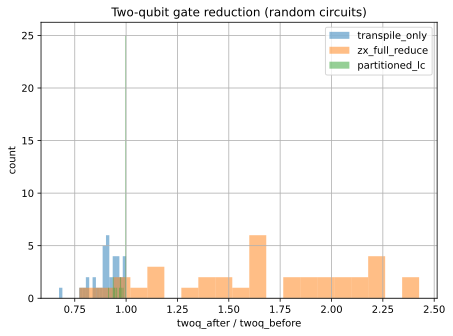

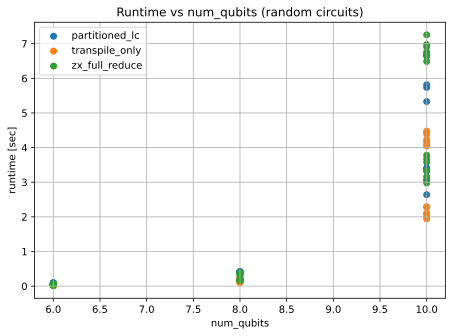

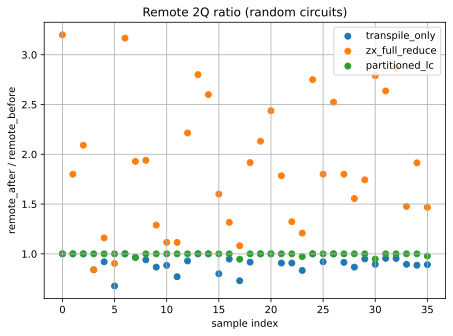

<Figure size 640x480 with 0 Axes>

In [ ]:
# --------------------------------------------
# ベンチマーク設定
# --------------------------------------------
nq_list = [6, 8, 10]
depth_list = [20, 40]
dens_list = [0.3, 0.7]

# remote / local の重み（実効コスト用）
processors_for_eval = 2      # 評価用に想定するプロセッサ数
remote_weight = 5.0          # remote 1個 = local 5個分（仮）
local_weight = 1.0

# クラスタ回路用の構造パラメータ
cluster_processors = 2       # クラスタ数 = プロセッサ数とみなす
intra_density = 0.8          # クラスタ内 CX 密度（高め）
inter_density = 0.05         # クラスタ間 CX 密度（低め）

# --------------------------------------------
# パイプラインラッパ
# --------------------------------------------

def _transpile_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return transpile_only_pipeline(qc, name="transpile_only")

def _zx_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return lc_pipeline(qc, name="zx_full_reduce")

def _partitioned_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return partitioned_lc_pipeline(
        qc,
        processors=cluster_processors,
        name="partitioned_lc",
    )

pipelines = [_transpile_wrapper, _zx_wrapper, _partitioned_wrapper]

# --------------------------------------------
# (1) 完全ランダム回路でのベンチマーク
#     → benchmark_pipeline_on_random をそのまま利用
# --------------------------------------------

samples_random: list[BenchmarkSample] = []

for pipe_fn in pipelines:
    samples = benchmark_pipeline_on_random(
        pipeline_fn=pipe_fn,
        num_qubits_list=nq_list,
        depth_list=depth_list,
        cx_density_list=dens_list,
        shots_per_setting=3,
        seed_offset=0,
        processors_for_eval=processors_for_eval,
        remote_weight=remote_weight,
        local_weight=local_weight,
    )
    samples_random.extend(samples)

# --------------------------------------------
# (2) クラスタ構造あり回路でのベンチマーク
#     → 手書きループで remote / cost も評価
# --------------------------------------------

def run_clustered_benchmark_for_pipeline(
    pipeline_fn,
    seed_offset: int = 1000,
) -> list[BenchmarkSample]:
    res_list: list[BenchmarkSample] = []
    base_seed = seed_offset

    for nq in nq_list:
        for d in depth_list:
            for dens in dens_list:  # dens は generator 内では使わないがインタフェース合わせで回す
                for s in range(3):
                    seed = base_seed + s

                    # クラスタ構造ありランダム回路
                    qc_rand = random_clustered_cx_circuit(
                        num_qubits=nq,
                        depth=d,
                        processors=cluster_processors,
                        intra_density=intra_density,
                        inter_density=inter_density,
                        seed=seed,
                    )
                    qc_rand = decompose_to_basis(qc_rand)

                    res = pipeline_fn(qc_rand)

                    # -------- remote / cost 評価 --------
                    remote_before = None
                    remote_after = None
                    eff_before = None
                    eff_after = None

                    if processors_for_eval is not None and processors_for_eval > 1:
                        base_circ = res.qc_in
                        n_eval = base_circ.num_qubits
                        p_eval = min(processors_for_eval, n_eval)
                        if p_eval < 1:
                            p_eval = 1

                        base_size = n_eval // p_eval
                        rem_q = n_eval % p_eval
                        sizes = [
                            base_size + (1 if i < rem_q else 0)
                            for i in range(p_eval)
                        ]

                        G = build_interaction_graph(base_circ)
                        part_of = kway_partition(G, sizes)

                        remote_before, local_before = count_remote_twoq(base_circ, part_of)
                        remote_after, local_after = count_remote_twoq(res.qc_out, part_of)

                        eff_before = remote_weight * remote_before + local_weight * local_before
                        eff_after = remote_weight * remote_after + local_weight * local_after

                    # -------- BenchmarkSample 追加 --------
                    res_list.append(
                        BenchmarkSample(
                            pipeline=res.name,
                            num_qubits=nq,
                            depth=d,
                            cx_density=dens,
                            seed=seed,
                            twoq_before=res.twoq_before,
                            twoq_after=res.twoq_after,
                            depth_before=res.depth_before,
                            depth_after=res.depth_after,
                            runtime_sec=res.runtime_sec,
                            remote_before=remote_before,
                            remote_after=remote_after,
                            eff_cost_before=eff_before,
                            eff_cost_after=eff_after,
                        )
                    )

    return res_list

samples_clustered: list[BenchmarkSample] = []
for i, pipe_fn in enumerate(pipelines):
    samples_clustered.extend(
        run_clustered_benchmark_for_pipeline(
            pipeline_fn=pipe_fn,
            seed_offset=1000 + 100 * i,
        )
    )

In [4]:
def _as_array(values: Iterable[float]) -> np.ndarray:
    return np.array(list(values), dtype=float)

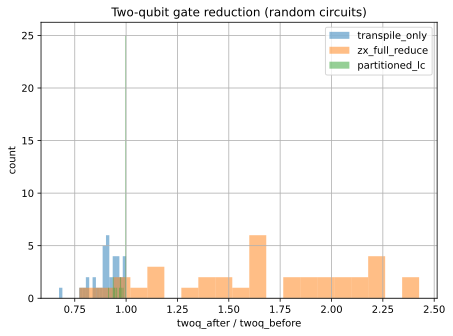

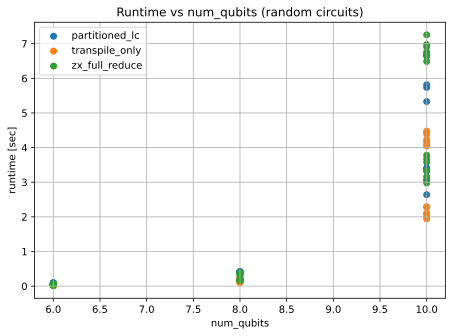

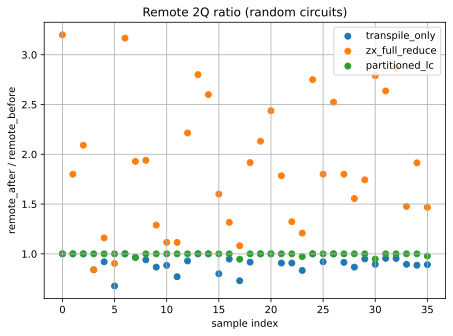

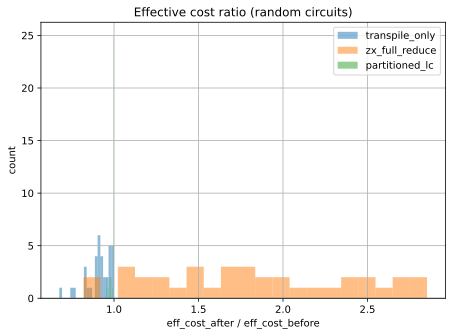

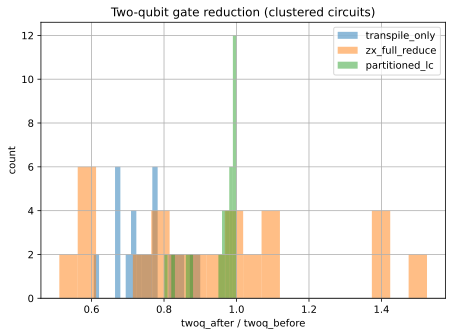

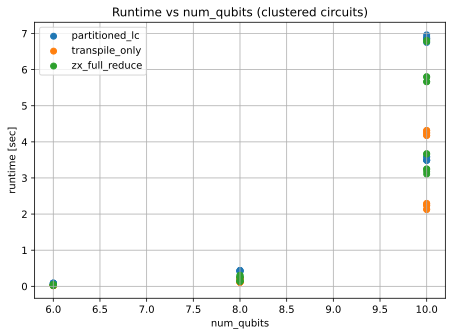

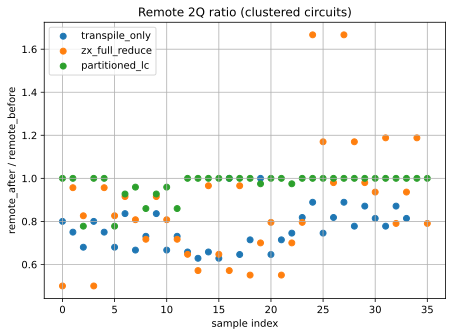

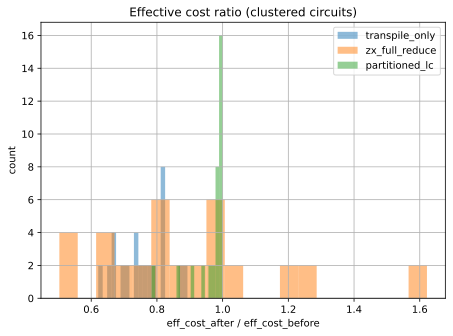

In [5]:
# --------------------------------------------
# 可視化
# --------------------------------------------

# ランダム回路
plot_twoq_reduction_hist(
    samples_random,
    title="Two-qubit gate reduction (random circuits)",
)
plot_runtime_vs_size(
    samples_random,
    title="Runtime vs num_qubits (random circuits)",
)
plot_remote_ratio(
    samples_random,
    title="Remote 2Q ratio (random circuits)",
)
plot_effective_cost_ratio(
    samples_random,
    title="Effective cost ratio (random circuits)",
)

# クラスタ回路
plot_twoq_reduction_hist(
    samples_clustered,
    title="Two-qubit gate reduction (clustered circuits)",
)
plot_runtime_vs_size(
    samples_clustered,
    title="Runtime vs num_qubits (clustered circuits)",
)
plot_remote_ratio(
    samples_clustered,
    title="Remote 2Q ratio (clustered circuits)",
)
plot_effective_cost_ratio(
    samples_clustered,
    title="Effective cost ratio (clustered circuits)",
)

plt.show()

In [6]:
def plot_remote_ratio_vs_density(
    samples: List[BenchmarkSample],
    title: str = "Remote 2Q ratio vs CX density",
) -> None:
    """
    remote_after / remote_before を cx_density ごとに平均し、
    パイプライン別に線グラフで描く。
    """
    plt.figure()

    # パイプラインと密度の組ごとに ratio を集める
    by_pipe_density: Dict[tuple[str, float], List[float]] = {}
    densities_set = set()
    pipelines_set = set()

    for s in samples:
        if s.remote_before is None or s.remote_before == 0:
            continue
        ratio = s.remote_after / s.remote_before
        key = (s.pipeline, float(s.cx_density))
        by_pipe_density.setdefault(key, []).append(ratio)
        densities_set.add(float(s.cx_density))
        pipelines_set.add(s.pipeline)

    densities_sorted = sorted(densities_set)

    for pipe in sorted(pipelines_set):
        xs: List[float] = []
        ys: List[float] = []
        for dens in densities_sorted:
            key = (pipe, dens)
            if key not in by_pipe_density:
                continue
            arr = _as_array(by_pipe_density[key])
            xs.append(dens)
            ys.append(arr.mean())
        if xs:
            plt.plot(xs, ys, marker="o", label=pipe)

    plt.xlabel("cx_density")
    plt.ylabel("mean(remote_after / remote_before)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

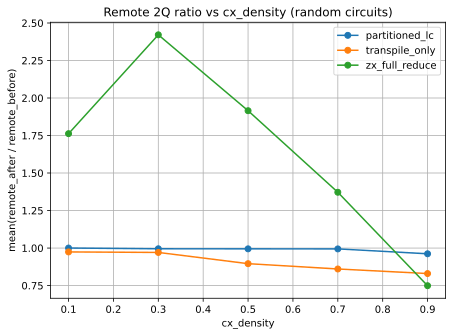

In [ ]:
# ------------------------------
# 共通設定
# ------------------------------
nq_list = [6, 8, 10]
depth_list = [20, 40]

# CX 密度を細かめに掃引
cx_density_list = [0.1, 0.3, 0.5, 0.7, 0.9]

processors_for_eval = 2   # remote 評価用に想定するプロセッサ数
remote_weight = 5.0
local_weight = 1.0

# ------------------------------
# パイプライン wrapper
# ------------------------------
def _transpile_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return transpile_only_pipeline(qc, name="Qiskit Transpiler")

def _zx_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return lc_pipeline(qc, name="pyzx")

def _partitioned_wrapper(qc: QuantumCircuit) -> PipelineResult:
    return partitioned_lc_pipeline(
        qc,
        processors=processors_for_eval,
        name="partitioned LC",
    )

pipelines = [_transpile_wrapper, _zx_wrapper, _partitioned_wrapper]

# ------------------------------
# (1) ランダム回路で CX 密度掃引
# ------------------------------
samples_random: List[BenchmarkSample] = []

for pipe_fn in pipelines:
    samples = benchmark_pipeline_on_random(
        pipeline_fn=pipe_fn,
        num_qubits_list=nq_list,
        depth_list=depth_list,
        cx_density_list=cx_density_list,
        shots_per_setting=3,
        seed_offset=0,
        processors_for_eval=processors_for_eval,
        remote_weight=remote_weight,
        local_weight=local_weight,
    )
    samples_random.extend(samples)

plot_remote_ratio_vs_density(
    samples_random,
    title="Remote 2Q ratio vs cx_density (random circuits)",
)

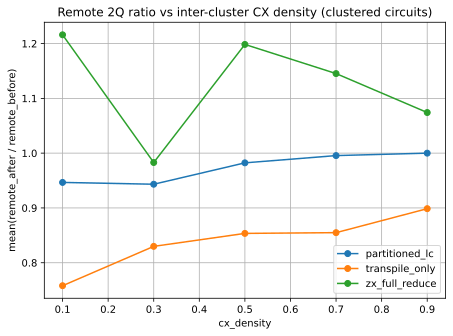

In [8]:
# ------------------------------
# (2) クラスタ構造あり回路で CX 密度掃引
#     → cx_density を inter-cluster CX 密度として扱う
# ------------------------------
cluster_processors = processors_for_eval   # プロセッサ数 = クラスタ数とみなす
intra_density = 0.8                       # クラスタ内は常に高密度

def run_clustered_vs_density_for_pipeline(
    pipeline_fn,
    seed_offset: int = 1000,
) -> List[BenchmarkSample]:
    res_list: List[BenchmarkSample] = []
    base_seed = seed_offset

    for nq in nq_list:
        for d in depth_list:
            for dens in cx_density_list:  # ここでは dens = inter_density として扱う
                for s in range(3):
                    seed = base_seed + s

                    qc_rand = random_clustered_cx_circuit(
                        num_qubits=nq,
                        depth=d,
                        processors=cluster_processors,
                        intra_density=intra_density,
                        inter_density=dens,
                        seed=seed,
                    )
                    qc_rand = decompose_to_basis(qc_rand)

                    res = pipeline_fn(qc_rand)

                    # -------- remote / cost 評価 --------
                    remote_before = None
                    remote_after = None
                    eff_before = None
                    eff_after = None

                    if processors_for_eval is not None and processors_for_eval > 1:
                        base_circ = res.qc_in
                        n_eval = base_circ.num_qubits
                        p_eval = min(processors_for_eval, n_eval)
                        if p_eval < 1:
                            p_eval = 1

                        base_size = n_eval // p_eval
                        rem_q = n_eval % p_eval
                        sizes = [
                            base_size + (1 if i < rem_q else 0)
                            for i in range(p_eval)
                        ]

                        G = build_interaction_graph(base_circ)
                        part_of = kway_partition(G, sizes)

                        remote_before, local_before = count_remote_twoq(base_circ, part_of)
                        remote_after, local_after = count_remote_twoq(res.qc_out, part_of)

                        eff_before = remote_weight * remote_before + local_weight * local_before
                        eff_after = remote_weight * remote_after + local_weight * local_after

                    res_list.append(
                        BenchmarkSample(
                            pipeline=res.name,
                            num_qubits=nq,
                            depth=d,
                            cx_density=dens,   # ここに inter_density をそのまま入れる
                            seed=seed,
                            twoq_before=res.twoq_before,
                            twoq_after=res.twoq_after,
                            depth_before=res.depth_before,
                            depth_after=res.depth_after,
                            runtime_sec=res.runtime_sec,
                            remote_before=remote_before,
                            remote_after=remote_after,
                            eff_cost_before=eff_before,
                            eff_cost_after=eff_after,
                        )
                    )

    return res_list

samples_clustered: List[BenchmarkSample] = []
for i, pipe_fn in enumerate(pipelines):
    samples_clustered.extend(
        run_clustered_vs_density_for_pipeline(
            pipeline_fn=pipe_fn,
            seed_offset=1000 + 100 * i,
        )
    )

plot_remote_ratio_vs_density(
    samples_clustered,
    title="Remote 2Q ratio vs inter-cluster CX density (clustered circuits)",
)

plt.show()

In [10]:
import numpy as np

def summarize_eff_cost(
    samples: List[BenchmarkSample],
    label: str = "",
) -> None:
    """
    各パイプラインごとに eff_cost_after / eff_cost_before の
    平均・std・min・max を表示する。
    """
    print("=" * 60)
    print(f"Eff-cost summary {('- ' + label) if label else ''}")
    print("=" * 60)

    by_pipe: Dict[str, List[float]] = {}

    for s in samples:
        if s.eff_cost_before is None or s.eff_cost_before == 0:
            continue
        ratio = s.eff_cost_after / s.eff_cost_before
        by_pipe.setdefault(s.pipeline, []).append(ratio)

    for name, ratios in sorted(by_pipe.items()):
        arr = np.array(ratios, dtype=float)
        print(
            f"{name:16s}  "
            f"mean={arr.mean():.3f}, "
            f"std={arr.std():.3f}, "
            f"min={arr.min():.3f}, "
            f"max={arr.max():.3f}, "
            f"n={len(arr)}"
        )

    if not by_pipe:
        print("no eff_cost data found (eff_cost_before is None/0 everywhere)")

In [12]:
def summarize_eff_cost_wins(
    samples: List[BenchmarkSample],
    label: str = "",
    base_pipeline: str = "transpile_only",
    target_pipeline: str = "partitioned_lc",
) -> None:
    """
    同じ設定（nq, depth, cx_density, seed）の中で
    eff_cost ratio が最小のパイプラインを数える。
    特に base_pipeline vs target_pipeline の直接対決の勝率も出す。
    """
    print("=" * 60)
    print(f"Eff-cost wins {('- ' + label) if label else ''}")
    print("=" * 60)

    # key = (nq, depth, cx_density, seed) ごとに pipeline -> ratio を集める
    by_key: Dict[tuple, Dict[str, float]] = {}
    pipelines_set = set()

    for s in samples:
        if s.eff_cost_before is None or s.eff_cost_before == 0:
            continue
        key = (s.num_qubits, s.depth, float(s.cx_density), s.seed)
        ratio = s.eff_cost_after / s.eff_cost_before
        d = by_key.setdefault(key, {})
        d[s.pipeline] = ratio
        pipelines_set.add(s.pipeline)

    pipelines = sorted(pipelines_set)
    wins: Dict[str, int] = {p: 0 for p in pipelines}
    total = 0

    # 全パイプラインの中で最小 ratio を持つやつに 1 win
    for key, d in by_key.items():
        if len(d) < 2:
            continue
        total += 1
        best_p = min(d.items(), key=lambda kv: kv[1])[0]
        wins[best_p] += 1

    if total == 0:
        print("no comparable samples (need at least 2 pipelines per key)")
    else:
        print(f"Total comparable settings: {total}")
        for p in pipelines:
            w = wins[p]
            print(f"{p:16s} wins={w:4d}  ({w/total:.3f})")

    # base vs target の直接対決
    bt_total = 0
    bt_better = 0
    bt_worse = 0
    bt_tie = 0

    for key, d in by_key.items():
        if base_pipeline not in d or target_pipeline not in d:
            continue
        bt_total += 1
        r_base = d[base_pipeline]
        r_target = d[target_pipeline]
        if r_target < r_base:
            bt_better += 1
        elif r_target > r_base:
            bt_worse += 1
        else:
            bt_tie += 1

    print("-" * 60)
    print(f"{target_pipeline} vs {base_pipeline}")
    if bt_total == 0:
        print("no direct comparison samples")
    else:
        print(f"comparisons: {bt_total}")
        print(f"  {target_pipeline:16s} better: {bt_better:4d}  ({bt_better/bt_total:.3f})")
        print(f"  {target_pipeline:16s} worse : {bt_worse:4d}  ({bt_worse/bt_total:.3f})")
        print(f"  tie                    : {bt_tie:4d}  ({bt_tie/bt_total:.3f})")

In [13]:
# - random circuits → samples_random
# - clustered circuits → samples_clustered
#
# 例:
# samples_random = ...
# samples_clustered = ...

# eff_cost ratio の統計
summarize_eff_cost(samples_random, label="random circuits")
summarize_eff_cost(samples_clustered, label="clustered circuits")

# 勝率（どのパイプラインが最小 eff_cost ratio か）
summarize_eff_cost_wins(samples_random, label="random circuits")
summarize_eff_cost_wins(samples_clustered, label="clustered circuits")

Eff-cost summary - random circuits
partitioned_lc    mean=0.989, std=0.036, min=0.706, max=1.000, n=90
transpile_only    mean=0.906, std=0.084, min=0.676, max=1.000, n=90
zx_full_reduce    mean=1.594, std=0.637, min=0.489, max=2.852, n=90
Eff-cost summary - clustered circuits
partitioned_lc    mean=0.973, std=0.057, min=0.671, max=1.045, n=90
transpile_only    mean=0.841, std=0.072, min=0.664, max=0.959, n=90
zx_full_reduce    mean=1.082, std=0.256, min=0.626, max=1.801, n=90
Eff-cost wins - random circuits
Total comparable settings: 90
partitioned_lc   wins=   1  (0.011)
transpile_only   wins=  75  (0.833)
zx_full_reduce   wins=  14  (0.156)
------------------------------------------------------------
partitioned_lc vs transpile_only
comparisons: 90
  partitioned_lc   better:    2  (0.022)
  partitioned_lc   worse :   66  (0.733)
  tie                    :   22  (0.244)
Eff-cost wins - clustered circuits
no comparable samples (need at least 2 pipelines per key)
-----------------------